In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.5 MB/s eta 0:00:00


機器感知結果：


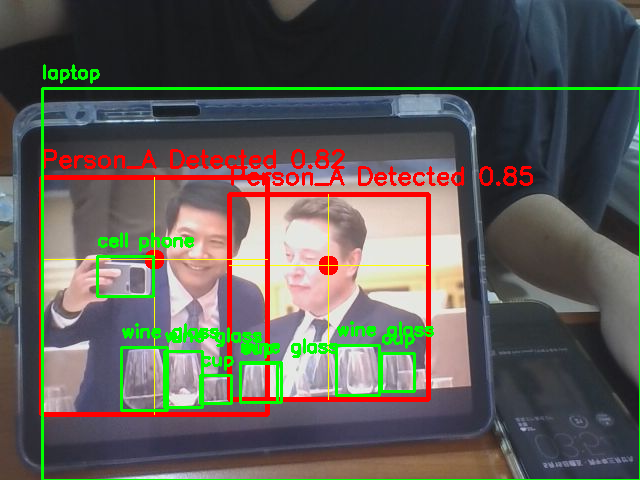

In [12]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import display, Javascript, clear_output
from google.colab.patches import cv2_imshow

# --- 1. 載入 YOLOv8 模型 ---
model = YOLO('yolov8n.pt')

# --- 2. JavaScript 手動拍照介面 ---
def take_photo_yolo(quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '📸 按下拍照並辨識';
      capture.style.cssText = "padding: 10px; font-size: 16px; margin-bottom: 10px; cursor: pointer;";

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.transform = 'scaleX(-1)'; // 讓預覽畫面像鏡子一樣翻轉
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(capture);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // 調整 Colab 顯示高度
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // 等待使用者按下按鈕
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      // 停止攝影機流
      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  image = cv2.imdecode(np.frombuffer(binary, dtype=np.uint8), -1)
  return image

# --- 3. 執行主程式 ---
try:
    print("請點擊下方的按鈕來進行拍照辨識...")
    # 呼叫手動拍照函數
    frame = take_photo_yolo()

    # 為了顯示習慣，將拍照結果也做鏡像翻轉（可視個人喜好）
    frame = cv2.flip(frame, 1)

    # YOLO 感知
    results = model(frame)

    # 4. 繪製邏輯 (仿照 image_7661da.jpg 的樣式)
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            label = model.names[cls]
            conf = box.conf[0]

            if label == 'person':
                # 繪製紅框與紅點 (鼻子位置預測)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 3)
                cx, cy = (x1 + x2) // 2, int(y1 + (y2 - y1) * 0.35)
                cv2.circle(frame, (cx, cy), 10, (0, 0, 255), -1)

                # 加上黃色網格輔助線
                cv2.line(frame, (x1, cy), (x2, cy), (0, 255, 255), 1)
                cv2.line(frame, (cx, y1), (cx, y2), (0, 255, 255), 1)

                cv2.putText(frame, f"Person_A Detected {conf:.2f}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            else:
                # 其他物件用綠色框
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, label, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # 最終顯示
    clear_output()
    print("機器感知結果：")
    cv2_imshow(frame)

except Exception as e:
    print(f"發生錯誤: {e}")